### Import packages

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import astropy.units as u
from datetime import datetime, timedelta
import sys, os, glob, pickle, tables
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import chi2, binned_statistic
pd.set_option('display.max_columns', None)
from astropy.coordinates import SkyCoord

sys.path.insert(0, os.getcwd() + "/../scripts/")
import geometry as geom
# import lstpipeline

# Filter parameters

In [2]:
# Source ------------
source_coordinates = SkyCoord.from_name("crab")
# Select here the desired range of telescope pointings around the source. 
# The values below are for standard wobble observations (0.4 deg source offset)
min_angle_to_source = 0.35 * u.deg
max_angle_to_source = 0.45 * u.deg

####################################
# --- POWER LAW PARAMETERS REF --- #
ref_p0 =  1.74 
ref_p1 = -2.23
####################################

# mean intensity power index -----------
min_pindex   = np.nan # -2.4
max_pindex   = np.nan # -2.0
max_u_pindex = np.nan # 0.2

# run lengths ------
min_run_length = np.nan # 40
max_run_length = np.nan # 30 * 60

# cosmic rates ------
min_bad_rates            = 0.2
threshold_good_bad_rates = 1.4
max_good_rates           = 2.
max_u_rates              = 0.05

# dates defined as "good" -------
min_date_good = datetime.fromisoformat("2022-11-18")
max_date_good = datetime.fromisoformat("2023-02-14")

min_date_paper = datetime.fromisoformat("2020-10-01")
max_date_paper = datetime.fromisoformat("2022-04-25")

# weather thresholds -------
threshold_tng_dust = 2.
threshold_humidity = 60.

### Paths and directories

In [3]:
# Root path of this script
root = os.getcwd() + "/"
# Objects directory
root_data = root + "../data/"

# Filename of the total dictionary
fname_dcheck_srunwise = root_data + "datachecks/dict_datachecks_srunwise.pkl"
fname_table_srunwise = root_data + "datachecks/table_datachecks_srunwise.csv"

### Reading the run-wise table

In [4]:
# Read DataFrame from CSV
df_runwise = pd.read_csv(fname_table_srunwise)
df_runwise = df_runwise.set_index("obs_id", inplace=False)
times_runwise = np.array([datetime.fromisoformat(t) for t in df_runwise["timestamp"]])

total_obs_time = sum(df_runwise["telapsed"]) / 3600
print(f"The total dataset contains {len(df_runwise)} runs, and observation time {total_obs_time:.2f}h")
display(df_runwise[:6])

The total dataset contains 7771 runs, and observation time 2090.97h


,Unnamed: 0,n_subruns,timestamp,telapsed,az,zd,ra,dec,cosmics_peak_rate,stdv_cosmics_peak_rate,cosmics_rate_at_422_pe,stdv_cosmics_rate_at_422_pe,intensity_at_half_peak_rate,stdv_intensity_at_half_peak_rate,delta_cosmics_rate_at_422_pe,stdv_delta_cosmics_rate_at_422_pe,cosmics_spectral_index,stdv_cosmics_spectral_index,delta_cosmics_spectral_index,stdv_delta_cosmics_spectral_index,ZD_corrected_cosmics_peak_rate,stdv_ZD_corrected_cosmics_peak_rate,ZD_corrected_cosmics_rate_at_422_pe,stdv_ZD_corrected_cosmics_rate_at_422_pe,ZD_corrected_intensity_at_half_peak_rate,stdv_ZD_corrected_intensity_at_half_peak_rate,ZD_corrected_delta_cosmics_rate_at_422_pe,stdv_ZD_corrected_delta_cosmics_rate_at_422_pe,ZD_corrected_cosmics_spectral_index,stdv_ZD_corrected_cosmics_spectral_index,intensity_spectrum_fit_p_value,diffuse_nsb_std,charge_mean,stdv_charge_mean,light_yield,run_drdi_fit_p0,run_drdi_fit_p1,run_drdi_fit_u_p0,run_drdi_fit_u_p1,run_drdi_fit_chi2,run_drdi_fit_pvalue,run_drdi_fit_ndf,run_drdi_fit_error_flag,temperature,pressure,humidity,wind_speed,wind_gust,wind_speed_average,tng_dust,tng_seeing,rain
obs_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1615,0,61,2019-11-23 23:40:47.731307,1479.185384,265.754848,31.359290,8.676201,22.059712,7.252669,0.108430,1.879985,0.029587,127.976556,1.207705,0.018524,0.007872,-2.179461,0.052953,0.059882,0.025505,9.615377,0.207266,2.045992,0.024084,124.759916,1.190506,0.020157,0.008575,-2.126104,0.053143,0.426504,1.465696,1.843949,0.015313,1.155216,2.051726,-0.000015,0.007395,0.000008,167.713018,7.749357e-13,57,False,7.588689,787.011475,45.536721,14.823115,18.493115,14.341311,0.380000,1.710000,0.0
1616,1,62,2019-11-24 00:11:26.987927,1492.465697,95.332874,30.722616,83.659785,21.844168,7.338338,0.111450,1.923990,0.028007,127.591533,1.268291,0.019916,0.007579,-2.165521,0.048141,0.062913,0.023863,9.644406,0.193980,2.085128,0.018315,124.538413,1.282795,0.021588,0.008210,-2.114527,0.046639,0.383385,1.678245,2.113709,0.006173,1.176689,2.077890,0.000015,0.005083,0.000006,75.387183,1.017617e-01,61,False,7.951452,786.889839,46.629677,14.410645,18.621774,14.384194,0.277419,2.077581,0.0
1617,2,35,2019-11-24 00:45:42.507987,877.161720,273.215706,44.511343,8.675483,22.076830,6.785111,0.082079,1.655979,0.025860,127.771350,0.929714,0.015800,0.007686,-2.245861,0.073846,0.058021,0.028475,10.181520,0.112144,2.049730,0.018668,118.418470,1.154316,0.019581,0.009608,-2.127638,0.073560,0.495740,1.490406,1.873624,0.007748,1.157435,2.043657,0.000024,0.005334,0.000010,44.641273,8.496942e-02,33,False,7.710571,786.620000,51.568000,14.998286,19.397429,15.432286,0.260000,2.140000,0.0
1618,3,81,2019-11-24 01:07:29.246502,1822.499924,108.322078,18.014448,83.668157,21.922445,7.559337,0.107014,2.114495,0.213096,126.812227,1.208264,0.037531,0.064773,-2.067526,0.386137,0.094747,0.130588,8.332031,0.166631,2.164965,0.212443,125.807134,1.174829,0.038297,0.065847,-2.051108,0.385296,0.395566,1.690460,2.128744,0.011473,1.160424,2.105509,0.000009,0.005707,0.000007,310.499037,0.000000e+00,75,False,7.585802,786.379877,60.808272,14.600370,19.541605,13.873580,0.086790,2.463827,0.0
1619,4,30,2019-11-24 01:45:25.986127,922.360651,279.314177,57.571760,8.704526,22.086164,5.736650,0.153067,1.272401,0.041651,126.917053,1.125708,0.013388,0.006202,-2.304494,0.063341,0.063585,0.028160,8.413803,0.245827,2.045831,0.022481,112.330784,0.997127,0.021450,0.009606,-2.085522,0.060519,0.460160,1.544312,1.935010,0.005709,1.161393,2.052083,-0.000015,0.006106,0.000012,29.995632,3.634267e-01,28,False,7.658333,786.082000,58.738667,16.784667,21.891333,15.738000,0.030000,2.570000,0.0
1620,5,78,2019-11-24 02:03:06.030581,1748.229183,148.833255,8.163757,83.531399,21.910342,7.611171,0.109814,2.089467,0.023459,125.458750,1.248303,0.021311,0.008589,-2.126284,0.056065,0.061951,0.024808,7.758958,0.122439,2.099011,0.024965,125.248930,1.234054,0.021409,0.008629,-2.123014,0.056155,0.397674,1.695722,2.125367,0.013739,1.182556,2.134920,-0.000044,0.004465,0.000004,87.920147,1

## Creating performance paper dataset

In [5]:
runs_performance_paper = [ 
    2914, 2929, 2930, 2931, 2932, 2933, 2934, 2949, 2950, 2967, 2968,
    2969, 2970, 2971, 2972, 2973, 2974, 2975, 2976, 2977, 2988, 2989,
    2990, 2991, 2992, 3004, 3005, 3006, 3007, 3008, 3093, 3094, 3095,
    3096, 3231, 3232, 3243, 3270, 3271, 3272, 3273, 3274, 3275, 3276,
    3277, 3278, 3279, 3318, 3319, 3320, 3321, 3328, 3329, 3330, 3338,
    3339, 3340, 3355, 3356, 3373, 3598, 3599, 3600, 3601, 3615, 3632,
    3633, 3634, 3635, 3672, 3673, 3674, 3675, 3676, 3677, 3706, 3707,
    3708, 4067, 4068, 4086, 4087, 6045, 6073, 6304, 6872, 6873, 6874,
    6875, 6892, 6893, 6894, 6895, 7097, 7098, 7099, 7133, 7136, 7161,
    7195, 7196, 7197, 7199, 7200, 7227, 7228, 7231, 7232, 7233, 7253,
    7254, 7255, 7256, 7274, 7275, 7276, 7277
]

df_performance = df_runwise.loc[runs_performance_paper]
times_performance = np.array([datetime.fromisoformat(t) for t in df_performance["timestamp"]])

total_obs_time = sum(df_performance["telapsed"]) / 3600
print(f"The performance paper dataset contains {len(df_performance)} runs, and observation time {total_obs_time:.2f}h")

The performance paper dataset contains 117 runs, and observation time 35.87h


# Filtering Crab only observations

In [6]:
telescope_pointing  = SkyCoord(ra=np.array(df_runwise["ra"])*u.deg, dec=np.array(df_runwise["dec"])*u.deg)
angular_distance    = source_coordinates.separation(telescope_pointing)
skyregion_selection = ((angular_distance > min_angle_to_source) & (angular_distance < max_angle_to_source))

df_crab = df_runwise[skyregion_selection]
times_crab = np.array([datetime.fromisoformat(t) for t in df_crab["timestamp"]])

total_obs_time = sum(df_crab["telapsed"]) / 3600
print(f"\nThe crab dataset contains {len(df_crab)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_crab)/len(df_runwise)*100:.1f}% of the runs\n")


The crab dataset contains 1259 runs, and observation time 339.46h
 - 16.2% of the runs



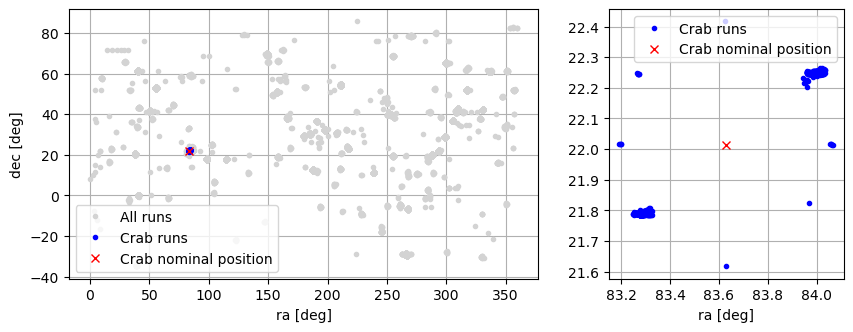

In [7]:
fig, (ax, axz) = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={'width_ratios': [2, 1]})


ax.plot(df_runwise["ra"], df_runwise["dec"], marker=".", ls="", color="lightgray", label="All runs")
ax.plot(df_crab["ra"], df_crab["dec"], marker=".", ls="", color="b", label="Crab runs")
axz.plot(df_crab["ra"], df_crab["dec"], marker=".", ls="", color="b", label="Crab runs")

for axe in [ax, axz]:
    axe.plot(source_coordinates.ra.deg, source_coordinates.dec.deg, marker="x", ls="", color="r", label="Crab nominal position")
    axe.set_xlabel("ra [deg]"); axe.legend(); axe.grid()
ax.set_ylabel("dec [deg]")

# plt.savefig(f"plots/plot.png", bbox_inches="tight", dpi=300)
plt.show()

# Filtering by slope

In [8]:
conditions_query_pindex = []
if ~np.isnan(max_pindex):
    conditions_query_pindex.append(f"cosmics_spectral_index < {max_pindex}")
if ~np.isnan(min_pindex):
    conditions_query_pindex.append(f"cosmics_spectral_index > {min_pindex}")
if ~np.isnan(max_u_pindex):
    conditions_query_pindex.append(f"delta_cosmics_spectral_index < {max_u_pindex}")
string_conditions_query_pindex = "&".join(conditions_query_pindex)

if string_conditions_query_pindex != "":
    df_slope_filtered = df_crab.query(string_conditions_query_pindex)
else:
    df_slope_filtered = df_crab.copy()

total_obs_time = sum(df_slope_filtered["telapsed"]) / 3600
print(f"\nThe slope filtered ({min_pindex:.2f} < slope < {max_pindex:.2f}):")
print(f"Dataset contains {len(df_slope_filtered)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_slope_filtered)/len(df_crab)*100:.1f}% of the runs\n")


The slope filtered (nan < slope < nan):
Dataset contains 1259 runs, and observation time 339.46h
 - 100.0% of the runs



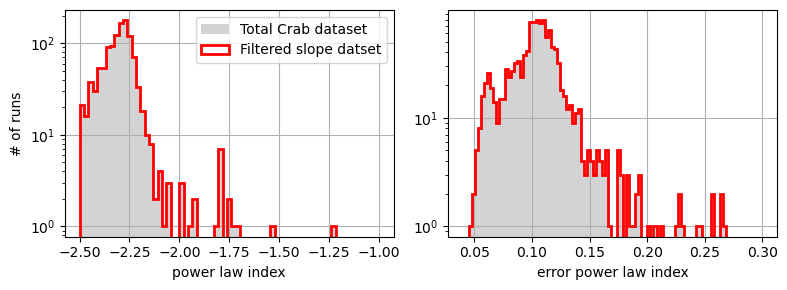

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

ax1.hist(df_crab["cosmics_spectral_index"], np.linspace(-2.5, -1, 70), 
         color="lightgray", label="Total Crab dataset")
ax1.hist(df_slope_filtered["cosmics_spectral_index"], np.linspace(-2.5, -1, 70), 
         color="r", histtype="step", lw=2, ls="-", label="Filtered slope datset")

ax2.hist(df_crab["delta_cosmics_spectral_index"], np.linspace(0.04, 0.3, 100), color="lightgray")
ax2.hist(df_slope_filtered["delta_cosmics_spectral_index"], np.linspace(0.04, 0.3, 100), 
         color="r", histtype="step", lw=2, ls="-", label="Filtered slope datset")

ax1.axvline(min_pindex, color="b", ls="--")
ax1.axvline(max_pindex, color="crimson", ls="--")
ax2.axvline(max_u_pindex, color="crimson", ls="--")

ax1.set_xlabel("power law index")
ax2.set_xlabel("error power law index")
ax1.set_ylabel("# of runs")
for ax in [ax1, ax2]:
    ax.set_yscale("log")
    ax.grid()
ax1.legend()
fig.tight_layout()

# plt.savefig(f"plots/plot.png", bbox_inches="tight", dpi=300)
plt.show()

# Filtering by run longitude

In [10]:
conditions_query_runlong = []
if ~np.isnan(max_run_length):
    conditions_query_runlong.append(f"telapsed < {max_run_length}")
if ~np.isnan(min_run_length):
    conditions_query_runlong.append(f"telapsed > {min_run_length}")
string_conditions_query_runlong = "&".join(conditions_query_pindex)

if string_conditions_query_pindex != "":
    df_runlong_filtered = df_slope_filtered.query(string_conditions_query_pindex)
else:
    df_runlong_filtered = df_slope_filtered.copy()


total_obs_time = sum(df_runlong_filtered["telapsed"]) / 3600
print(f"\nThe run lenght filtered ({min_run_length:.0f}s < length < {max_run_length/60:.1f} min):")
print(f"Dataset contains {len(df_runlong_filtered)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_runlong_filtered)/len(df_slope_filtered)*100:.1f}% of the runs\n")


The run lenght filtered (nans < length < nan min):
Dataset contains 1259 runs, and observation time 339.46h
 - 100.0% of the runs



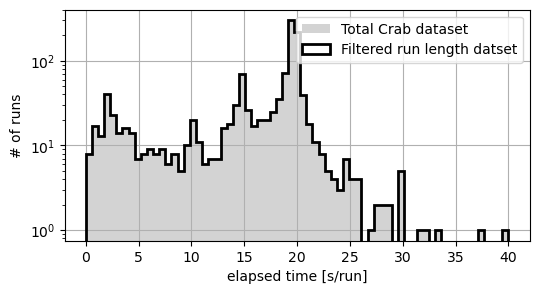

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

ax.hist(df_crab["telapsed"]/60, np.linspace(0, 40, 70), color="lightgray", label="Total Crab dataset")
ax.hist(df_runlong_filtered["telapsed"]/60, np.linspace(0, 40, 70), color="k", histtype="step", lw=2, label="Filtered run length datset")

ax.axvline(min_run_length/60, color="b", ls="--")
ax.axvline(max_run_length/60, color="crimson", ls="--")

ax.set_yscale("log")
ax.legend()
ax.set_xlabel("elapsed time [s/run]")
ax.set_ylabel("# of runs")
ax.grid()

# plt.savefig(f"plots/plot.png", bbox_inches="tight", dpi=300)
plt.show()

# Filtering good and bad rates runs

In [12]:
df_goodrates_filtered = df_runlong_filtered.query(
    f"ZD_corrected_cosmics_rate_at_422_pe > {threshold_good_bad_rates} & ZD_corrected_cosmics_rate_at_422_pe < {max_good_rates} & ZD_corrected_delta_cosmics_rate_at_422_pe < {max_u_rates}")
df_badrates_filtered  = df_runlong_filtered.query(
    f"ZD_corrected_cosmics_rate_at_422_pe < {threshold_good_bad_rates} & ZD_corrected_cosmics_rate_at_422_pe > {min_bad_rates} & ZD_corrected_delta_cosmics_rate_at_422_pe < {max_u_rates}")

print(f"\nThe \"good\" rate runs ({threshold_good_bad_rates:.2f} < rates @ 422 p.e. < {max_good_rates:.2f}):")
total_obs_time = sum(df_goodrates_filtered["telapsed"]) / 3600
print(f"Dataset contains {len(df_goodrates_filtered)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_goodrates_filtered)/len(df_runlong_filtered)*100:.1f}% of the runs\n")

print(f"\nThe \"bad\" rate runs ({min_bad_rates:.2f} < rates @ 422 p.e. < {threshold_good_bad_rates:.2f}):")
total_obs_time = sum(df_badrates_filtered["telapsed"]) / 3600
print(f"Dataset contains {len(df_badrates_filtered)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_badrates_filtered)/len(df_runlong_filtered)*100:.1f}% of the runs\n")


The "good" rate runs (1.40 < rates @ 422 p.e. < 2.00):
Dataset contains 963 runs, and observation time 260.59h
 - 76.5% of the runs


The "bad" rate runs (0.20 < rates @ 422 p.e. < 1.40):
Dataset contains 202 runs, and observation time 53.79h
 - 16.0% of the runs



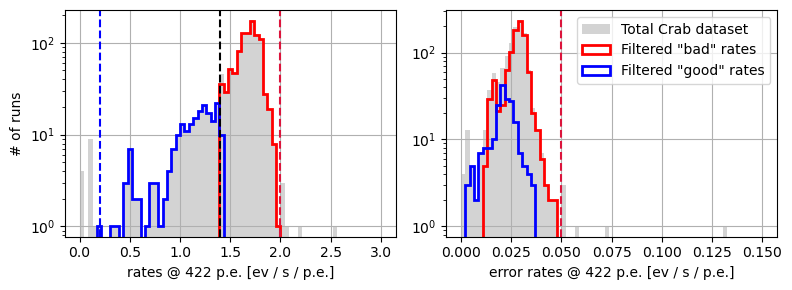

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

ax1.hist(df_crab["ZD_corrected_cosmics_rate_at_422_pe"], np.linspace(0, 3, 70), color="lightgray", label="Total Crab dataset")
ax1.hist(df_goodrates_filtered["ZD_corrected_cosmics_rate_at_422_pe"], np.linspace(0, 3, 70), color="r", histtype="step", lw=2, ls="-", label="Filtered \"bad\" rates")
ax1.hist(df_badrates_filtered["ZD_corrected_cosmics_rate_at_422_pe"], np.linspace(0, 3, 70), color="b", histtype="step", lw=2, ls="-", label="Filtered \"good\" rates")

ax2.hist(df_crab["ZD_corrected_delta_cosmics_rate_at_422_pe"], np.linspace(0, 0.15, 70), color="lightgray", label="Total Crab dataset")
ax2.hist(df_goodrates_filtered["ZD_corrected_delta_cosmics_rate_at_422_pe"], np.linspace(0, 0.15, 70), color="r", histtype="step", lw=2, ls="-", label="Filtered \"bad\" rates")
ax2.hist(df_badrates_filtered["ZD_corrected_delta_cosmics_rate_at_422_pe"], np.linspace(0, 0.15, 70), color="b", histtype="step", lw=2, ls="-", label="Filtered \"good\" rates")

ax1.axvline(min_bad_rates, color="b", ls="--")
ax1.axvline(threshold_good_bad_rates, color="k", ls="--")
ax1.axvline(max_good_rates, color="crimson", ls="--")
ax2.axvline(max_u_rates, color="crimson", ls="--")

ax1.set_xlabel("rates @ 422 p.e. [ev / s / p.e.]")
ax2.set_xlabel("error rates @ 422 p.e. [ev / s / p.e.]")
ax1.set_ylabel("# of runs")
for ax in [ax1, ax2]:
    ax.set_yscale("log"); ax.grid()
ax2.legend()
fig.tight_layout()

# plt.savefig(f"plots/plot.png", bbox_inches="tight", dpi=300)
plt.show()

# Good period runs

In [14]:
times_goodrates_filtered = np.array([datetime.fromisoformat(t) for t in df_goodrates_filtered["timestamp"]])
mask_good_period = ((times_goodrates_filtered > min_date_good) & (times_goodrates_filtered < max_date_good))

df_good_period   = df_goodrates_filtered[mask_good_period]
times_good_period = np.array([datetime.fromisoformat(t) for t in df_good_period["timestamp"]])

total_obs_time = sum(df_good_period["telapsed"]) / 3600
print("\nThe run lenght filtered ({} < date < {}):".format(
    str(min_date_good).split(" ")[0], str(max_date_good).split(" ")[0]))
print(f"Dataset contains {len(df_good_period)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_good_period)/len(df_goodrates_filtered)*100:.1f}% of the runs\n")


The run lenght filtered (2022-11-18 < date < 2023-02-14):
Dataset contains 330 runs, and observation time 75.53h
 - 34.3% of the runs



# Other good runs

In [15]:
df_good_others = df_goodrates_filtered[~mask_good_period]
df_good_others = df_good_others.query(f"obs_id not in @runs_performance_paper")
times_good_others = np.array([datetime.fromisoformat(t) for t in df_good_others["timestamp"]])

print(f"\nThe other \"good\" rate runs:")
total_obs_time = sum(df_good_others["telapsed"]) / 3600
print(f"Dataset contains {len(df_good_others)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_good_others)/len(df_goodrates_filtered)*100:.1f}% of the runs\n")


The other "good" rate runs:
Dataset contains 518 runs, and observation time 149.84h
 - 53.8% of the runs



# All performance paper period runs

In [16]:
times_crab = np.array([datetime.fromisoformat(t) for t in df_crab["timestamp"]])
mask_performance_period = ((times_crab > min_date_paper) & (times_crab < max_date_paper))

df_performance_period   = df_crab[mask_performance_period]
times_performance_period = np.array([datetime.fromisoformat(t) for t in df_performance_period["timestamp"]])

total_obs_time = sum(df_performance_period["telapsed"]) / 3600
print("\nThe run lenght filtered ({} < date < {}):".format(str(min_date_paper).split(" ")[0], str(max_date_paper).split(" ")[0]))
print(f"Dataset contains {len(df_performance_period)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_performance_period)/len(df_crab)*100:.1f}% of the runs\n")


The run lenght filtered (2020-10-01 < date < 2022-04-25):
Dataset contains 416 runs, and observation time 120.82h
 - 33.0% of the runs



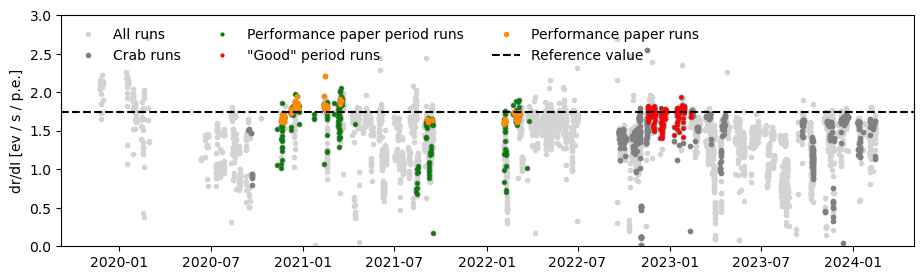

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(11, 3))

ax.plot(times_runwise, df_runwise["ZD_corrected_cosmics_rate_at_422_pe"], 
        ls="", marker=".", color="lightgray", label="All runs")
ax.plot(times_crab, df_crab["ZD_corrected_cosmics_rate_at_422_pe"], 
        ls="", marker=".", color="gray", label="Crab runs")

ax.plot(times_performance_period, df_performance_period["ZD_corrected_cosmics_rate_at_422_pe"], 
        ls="", marker=".", color="g", ms=4, label="Performance paper period runs")

ax.plot(times_good_period, df_good_period["ZD_corrected_cosmics_rate_at_422_pe"], 
        ls="", marker=".", color="r", ms=4, label="\"Good\" period runs")

ax.plot(times_performance, df_performance["ZD_corrected_cosmics_rate_at_422_pe"], 
        ls="", marker=".", color="darkorange", label="Performance paper runs")

ax.axhline(ref_p0, color="k", ls="--", label="Reference value")

ax.legend(loc=2, ncols=3, frameon=False)
ax.set_ylabel("dr/dI [ev / s / p.e.]")
ax.set_ylim(0, 3)

plt.savefig(f"plots/evolution_drdi_run_subsets_selection.png", bbox_inches="tight", dpi=300)
plt.show()

# Weather masking for the bad runs

In [18]:
df_good_weather = df_badrates_filtered.query(f"tng_dust < {threshold_tng_dust} & humidity < {threshold_humidity}")
df_bad_weather  = df_badrates_filtered.query(f"tng_dust > {threshold_tng_dust} | humidity > {threshold_humidity}")
times_good_weather = np.array([datetime.fromisoformat(t) for t in df_good_weather["timestamp"]])
times_bad_weather  = np.array([datetime.fromisoformat(t) for t in df_bad_weather["timestamp"]])

print(f"\nThe \"bad\" rates runs with good weather (tng_dust < {threshold_tng_dust:.1f}ug/m3 & humidity < {threshold_humidity}%):")
total_obs_time = sum(df_good_weather["telapsed"]) / 3600
print(f"Dataset contains {len(df_good_weather)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_good_weather)/len(df_badrates_filtered)*100:.1f}% of the runs\n")

print(f"\nThe \"bad\" rates runs with bad weather (tng_dust > {threshold_tng_dust:.1f}ug/m3 & humidity > {threshold_humidity}%):")
total_obs_time = sum(df_bad_weather["telapsed"]) / 3600
print(f"Dataset contains {len(df_bad_weather)} runs, and observation time {total_obs_time:.2f}h")
print(f" - {len(df_bad_weather)/len(df_badrates_filtered)*100:.1f}% of the runs\n")


The "bad" rates runs with good weather (tng_dust < 2.0ug/m3 & humidity < 60.0%):
Dataset contains 70 runs, and observation time 18.84h
 - 34.7% of the runs


The "bad" rates runs with bad weather (tng_dust > 2.0ug/m3 & humidity > 60.0%):
Dataset contains 116 runs, and observation time 30.98h
 - 57.4% of the runs



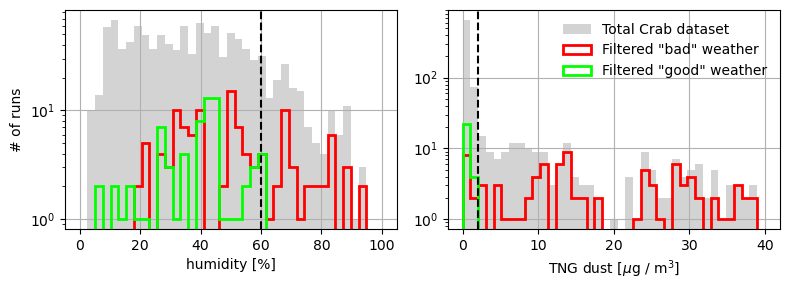

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

ax1.hist(df_crab["humidity"], np.linspace(0, 100, 40), color="lightgray", label="Total Crab dataset")
ax1.hist(df_bad_weather["humidity"], np.linspace(0, 100, 40), color="r", histtype="step", lw=2, ls="-", label="Filtered \"bad\" weather")
ax1.hist(df_good_weather["humidity"], np.linspace(0, 100, 40), color="lime", histtype="step", lw=2, ls="-", label="Filtered \"good\" weather")

ax2.hist(df_crab["tng_dust"], np.linspace(0, 40, 40), color="lightgray", label="Total Crab dataset")
ax2.hist(df_bad_weather["tng_dust"], np.linspace(0, 40, 40), color="r", histtype="step", lw=2, ls="-", label="Filtered \"bad\" weather")
ax2.hist(df_good_weather["tng_dust"], np.linspace(0, 40, 40), color="lime", histtype="step", lw=2, ls="-", label="Filtered \"good\" weather")

ax1.axvline(threshold_humidity, color="k", ls="--")
ax2.axvline(threshold_tng_dust, color="k", ls="--")

ax1.set_xlabel("humidity [%]")
ax2.set_xlabel("TNG dust [$\mu$g / m$^3$]")
ax1.set_ylabel("# of runs")
for ax in [ax1, ax2]:
    ax.set_yscale("log")
    ax.grid()
ax2.legend(frameon=False)
fig.tight_layout()

# plt.savefig(f"plots/plot.png", bbox_inches="tight", dpi=300)
plt.show()

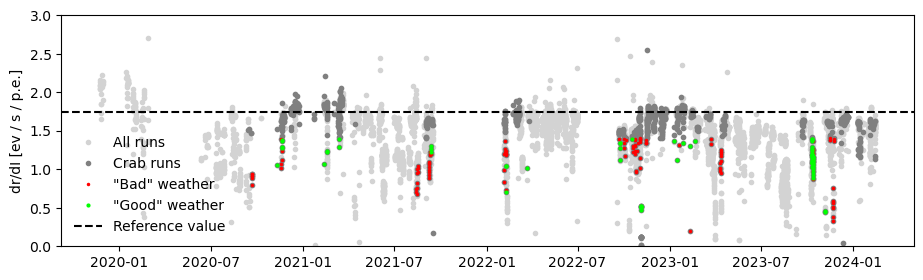

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(11, 3))

ax.plot(times_runwise, df_runwise["ZD_corrected_cosmics_rate_at_422_pe"], ls="", marker=".", color="lightgray", label="All runs")
ax.plot(times_crab, df_crab["ZD_corrected_cosmics_rate_at_422_pe"], ls="", marker=".", color="gray", label="Crab runs")

ax.plot(times_bad_weather, df_bad_weather["ZD_corrected_cosmics_rate_at_422_pe"], ls="", marker=".", color="r", ms=3, label="\"Bad\" weather")
ax.plot(times_good_weather, df_good_weather["ZD_corrected_cosmics_rate_at_422_pe"], ls="", marker=".", color="lime", ms=4, label="\"Good\" weather")

ax.axhline(ref_p0, color="k", ls="--", label="Reference value")

ax.legend(loc=3, frameon=False); ax.set_ylabel("dr/dI [ev / s / p.e.]"); ax.set_ylim(0, 3)

# plt.savefig(f"plots/plot.png", bbox_inches="tight", dpi=300)
plt.show()

In [21]:
print(f"\nPerformance paper runs: ({len(df_performance)})\n")
display(np.array(df_performance.index))

print(f"\n\n\"Good\" period runs: ({len(df_good_period)})\n")
display(np.array(df_good_period.index))

print(f"\n\nPerformance period runs: ({len(df_performance_period)})\n")
display(np.array(df_performance_period.index))

print(f"\n\nOther \"good\" runs: ({len(df_good_others)})\n")
display(np.array(df_good_others.index))

print(f"\n\n\"Bad\" rates good weather runs: ({len(df_good_weather)})\n")
display(np.array(df_good_weather.index))

print(f"\n\n\"Bad\" rates bad weather runs: ({len(df_bad_weather)})\n")
display(np.array(df_bad_weather.index))


Performance paper runs: (117)



array([2914, 2929, 2930, 2931, 2932, 2933, 2934, 2949, 2950, 2967, 2968,
       2969, 2970, 2971, 2972, 2973, 2974, 2975, 2976, 2977, 2988, 2989,
       2990, 2991, 2992, 3004, 3005, 3006, 3007, 3008, 3093, 3094, 3095,
       3096, 3231, 3232, 3243, 3270, 3271, 3272, 3273, 3274, 3275, 3276,
       3277, 3278, 3279, 3318, 3319, 3320, 3321, 3328, 3329, 3330, 3338,
       3339, 3340, 3355, 3356, 3373, 3598, 3599, 3600, 3601, 3615, 3632,
       3633, 3634, 3635, 3672, 3673, 3674, 3675, 3676, 3677, 3706, 3707,
       3708, 4067, 4068, 4086, 4087, 6045, 6073, 6304, 6872, 6873, 6874,
       6875, 6892, 6893, 6894, 6895, 7097, 7098, 7099, 7133, 7136, 7161,
       7195, 7196, 7197, 7199, 7200, 7227, 7228, 7231, 7232, 7233, 7253,
       7254, 7255, 7256, 7274, 7275, 7276, 7277])



"Good" period runs: (330)



array([10665, 10666, 10667, 10668, 10669, 10670, 10671, 10672, 10673,
       10674, 10855, 10856, 10857, 10858, 10859, 10860, 10861, 10862,
       10863, 10864, 10865, 10880, 10881, 10882, 10883, 10909, 10911,
       10912, 10913, 10914, 10915, 10916, 10917, 10918, 10919, 10920,
       10946, 10947, 10948, 10950, 10981, 10982, 10983, 10984, 10985,
       10986, 10987, 10988, 10989, 11014, 11015, 11016, 11017, 11018,
       11019, 11087, 11088, 11090, 11092, 11093, 11094, 11095, 11117,
       11118, 11119, 11120, 11121, 11122, 11123, 11124, 11125, 11126,
       11164, 11165, 11166, 11167, 11168, 11174, 11175, 11176, 11177,
       11178, 11179, 11180, 11181, 11182, 11183, 11185, 11186, 11187,
       11188, 11189, 11190, 11191, 11192, 11193, 11194, 11195, 11196,
       11197, 11198, 11199, 11208, 11209, 11210, 11219, 11220, 11221,
       11222, 11223, 11224, 11225, 11228, 11229, 11230, 11231, 11232,
       11233, 11235, 11236, 11237, 11238, 11239, 11240, 11241, 11243,
       11244, 11245,



Performance period runs: (416)



...

array([ 2691,  2692,  2758,  2759,  2853,  2913,  2919,  2922,  2923,
        2924,  2925,  2955,  2956,  2958,  2959,  2965,  2966,  3009,
        3010,  3011,  3012,  3087,  3088,  3089,  3090,  3097,  3098,
        3099,  3100,  3101,  3143,  3144,  3169,  3170,  3171,  3233,
        3234,  3235,  3236,  3237,  3244,  3245,  3264,  3265,  3266,
        3267,  3268,  3269,  3382,  3383,  3384,  3385,  3514,  3515,
        3516,  3584,  3585,  3586,  3616,  3631,  3636,  3637,  3638,
        3639,  3649,  3650,  3651,  3652,  3653,  3655,  3657,  3659,
        3678,  3679,  3680,  3681,  3682,  3683,  3684,  3703,  3704,
        3705,  3709,  3710,  3711,  3712,  3725,  3894,  3895,  3953,
        3954,  3955,  3956,  3957,  3959,  3960,  3961,  3962,  3974,
        3975,  3976,  3977,  3979,  3980,  3981,  3982,  4007,  4008,
        4009,  4010,  4011,  4012,  4013,  4014,  4015,  4027,  4028,
        4029,  4030,  4032,  4033,  4034,  4035,  4036,  4037,  4069,
        4073,  4074,



"Bad" rates good weather runs: (70)



array([ 2855,  2952,  2953,  2954,  2961,  3583,  3729,  3730,  3973,
        3983,  6240,  6241,  6242,  6968,  6969,  6992,  7434,  9367,
        9368,  9369,  9370,  9686, 10258, 10259, 10260, 10262, 10263,
       10330, 11611, 11629, 11858, 11953, 12001, 15018, 15019, 15020,
       15021, 15022, 15023, 15024, 15025, 15041, 15042, 15043, 15044,
       15045, 15046, 15047, 15048, 15049, 15050, 15051, 15054, 15055,
       15075, 15076, 15077, 15078, 15079, 15080, 15081, 15082, 15083,
       15084, 15085, 15086, 15088, 15089, 15272, 15273])



"Bad" rates bad weather runs: (116)



array([ 2766,  2767,  2768,  2769,  2770,  2771,  2916,  2917,  2918,
        2957,  2960,  5737,  5738,  5758,  5759,  5775,  5776,  5777,
        5798,  5799,  5800,  6146,  6147,  6166,  6167,  6168,  6169,
        6170,  6172,  6192,  6194,  6195,  6239,  6852,  6853,  6854,
        6943,  6944,  6945,  6962,  6963,  6964,  6965,  6966,  6990,
        9253,  9513,  9514,  9520,  9565,  9595,  9714,  9715,  9716,
        9849,  9851,  9852,  9853,  9856,  9858,  9880,  9882,  9945,
        9983, 10077, 10078, 10079, 10080, 10081, 10082, 10205, 10264,
       10525, 10526, 10527, 10528, 11717, 11954, 12378, 12379, 12597,
       12598, 12599, 12600, 12634, 12635, 12636, 12637, 12638, 12654,
       12655, 15122, 15123, 15124, 15125, 15127, 15128, 15129, 15130,
       15131, 15132, 15133, 15134, 15573, 15574, 15575, 15748, 15749,
       15750, 15751, 15752, 15753, 15767, 15768, 15778, 15779])